In [5]:
import numpy as np
import soundfile as sf
from IPython.display import Audio, display, Markdown
from hrtf import HRTF
from Trajectory import CircularTrajectory, LinearTrajectory
from DynamicSoundscape import DynamicSoundscape

# ── Constantes ────────────────────────────────────────────────────────────────
sr       = 44100
duration = 10
facteur  = 1 / np.sqrt(100_000)
t        = np.linspace(0, duration, sr * duration, endpoint=False)

# ── HRTF ─────────────────────────────────────────────────────────────────────
hrtf = HRTF.from_sofa("dataset/IRC_1002_C_44100.sofa")
print(hrtf)

# ── Signaux synthétiques ──────────────────────────────────────────────────────
sinus_LA = (facteur * np.sin(2 * np.pi * 440 * t)).astype(np.float32)

d_ref    = 2.06
d_t      = np.linspace(d_ref, 20.0, sr * duration)
sinus_FA = (facteur * np.sin(2 * np.pi * 349.23 * t) * (d_ref / d_t)).astype(np.float32)

print(f"Signaux prêts : duration={duration}s  sr={sr} Hz")


HRTF(positions=187, samples=512, sr=44100 Hz, source='IRC_1002_C_44100.sofa')
Signaux prêts : duration=10s  sr=44100 Hz


### Source 1

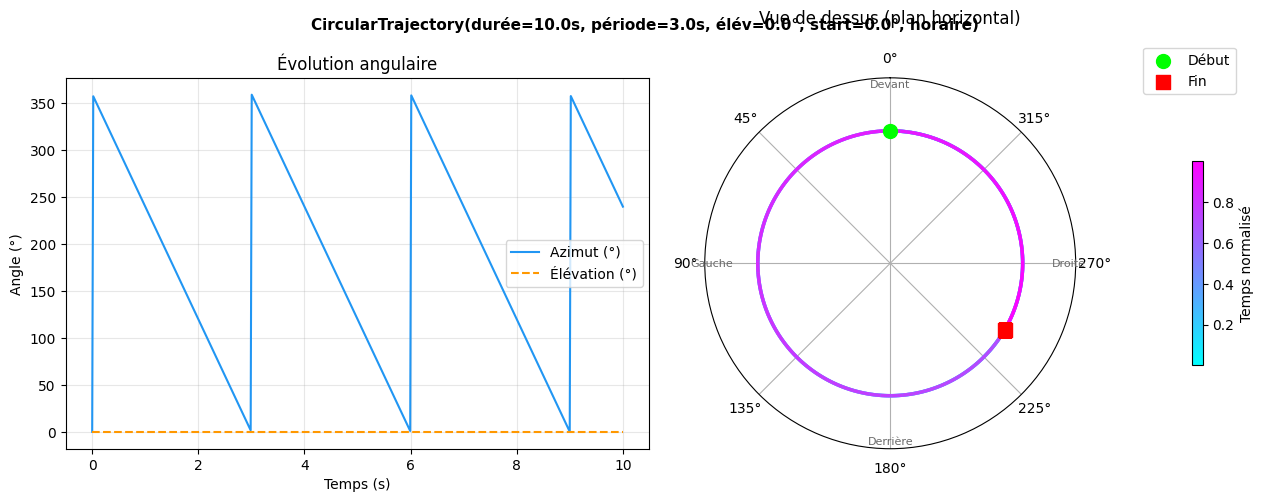

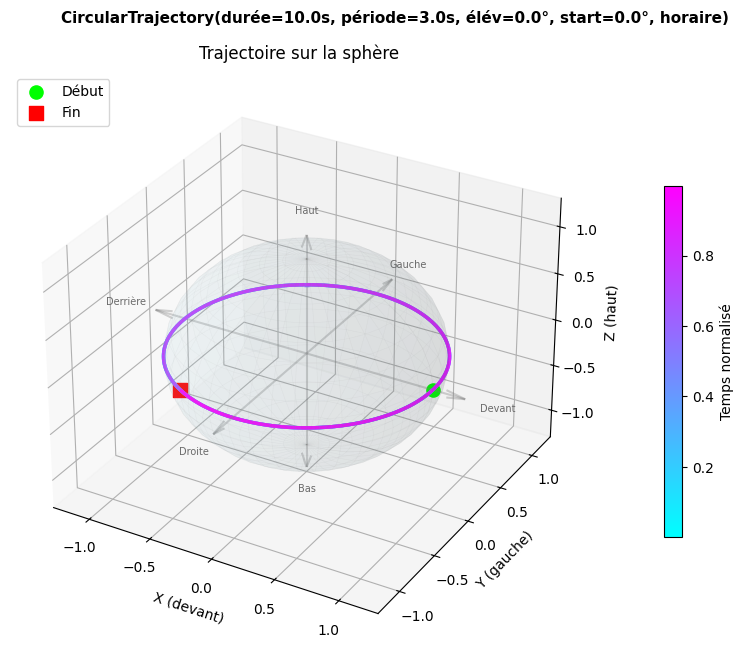

### Source 2

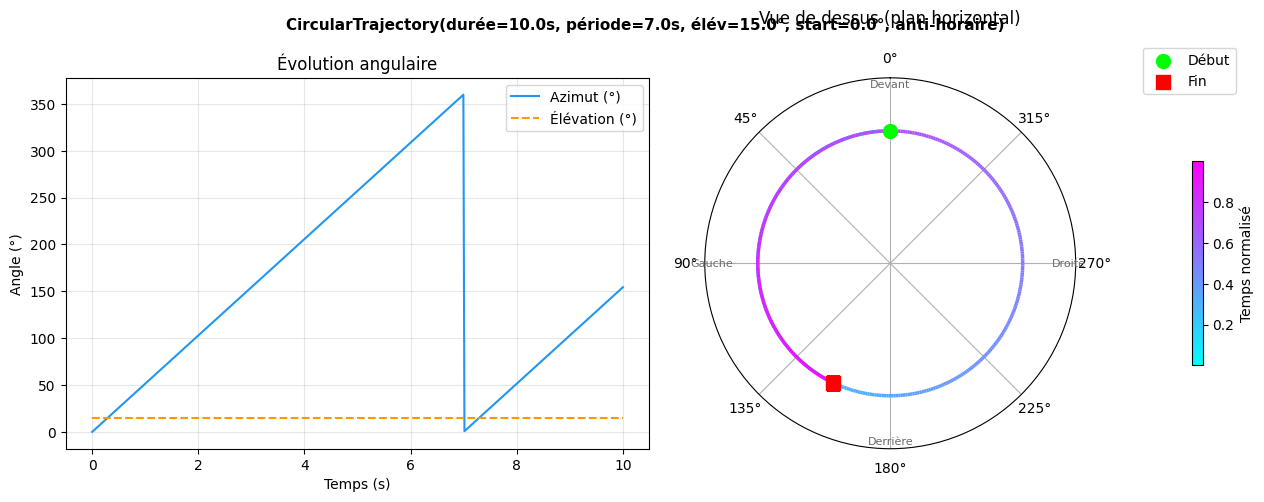

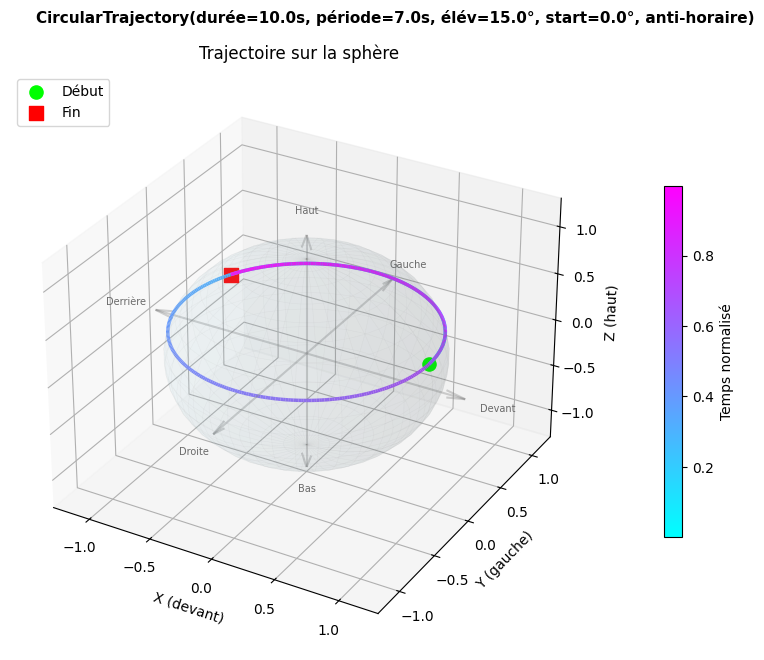

### Source 3

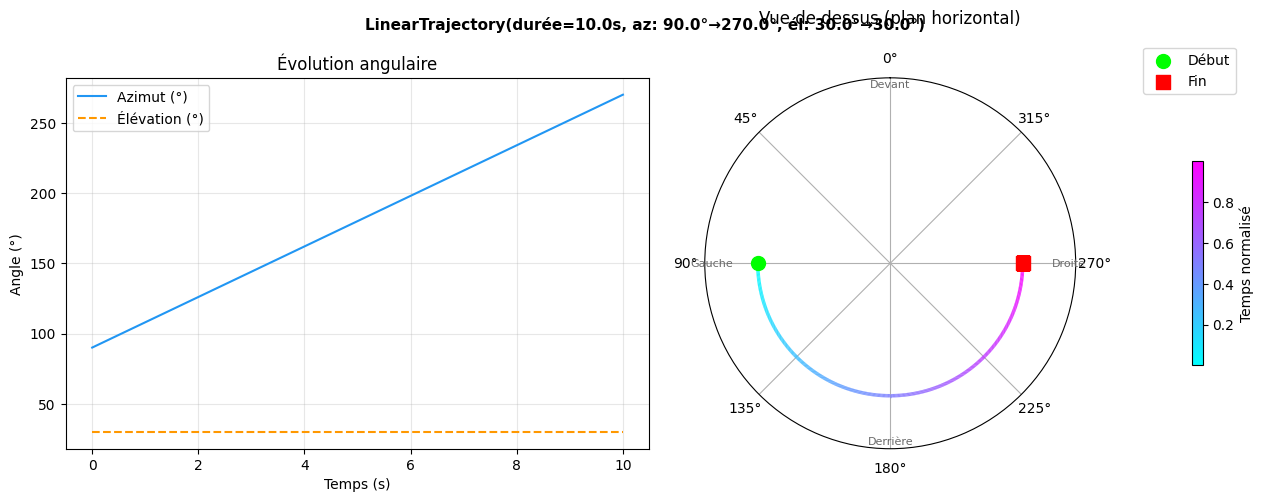

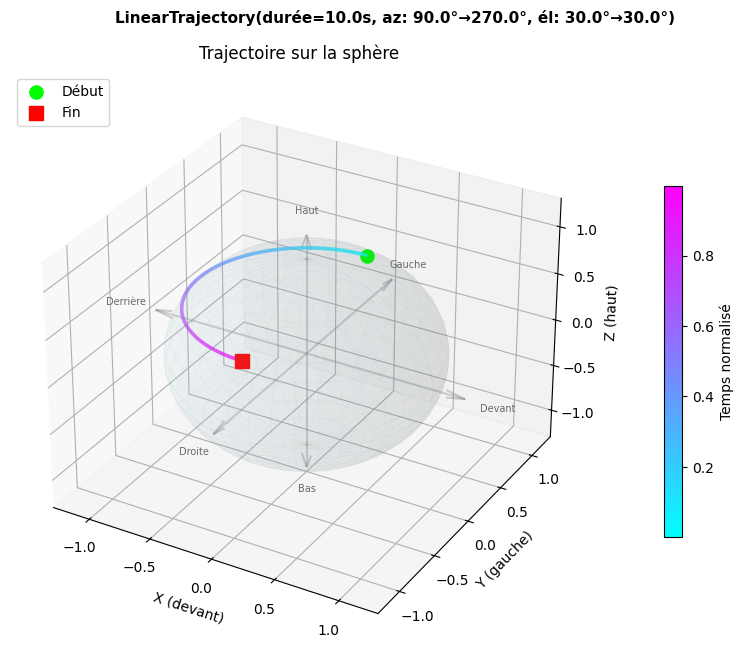

### Source 4

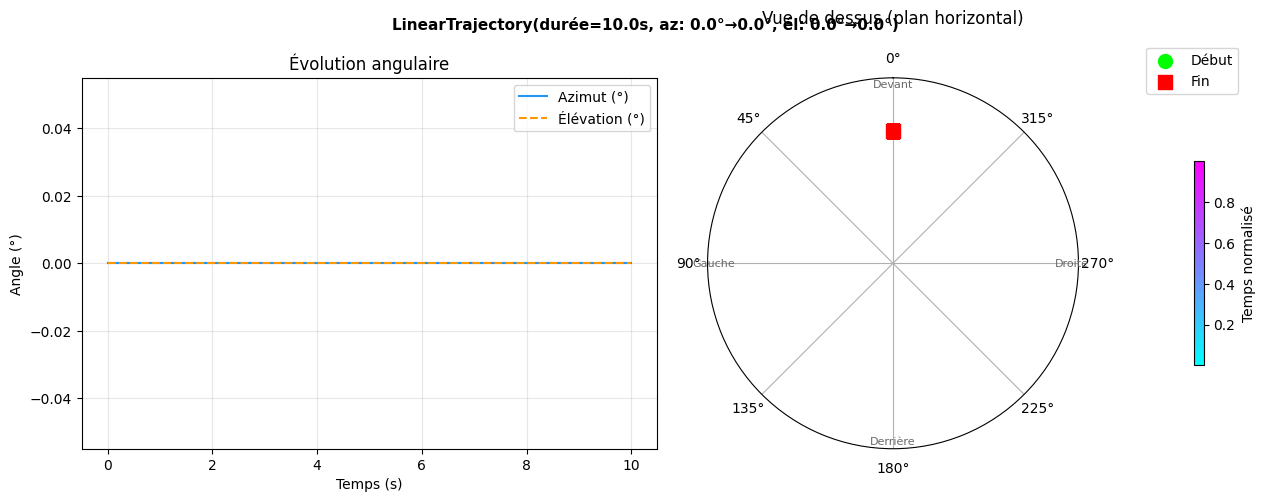

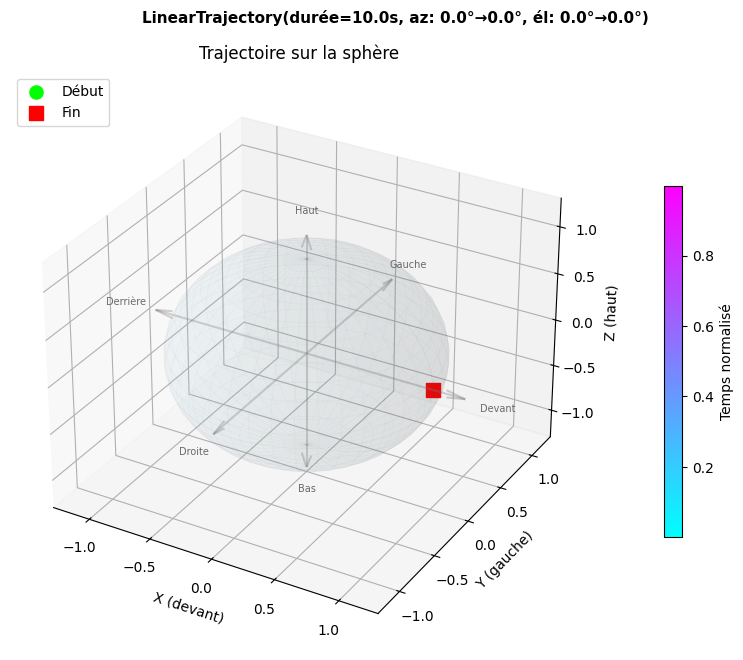

In [9]:
# Source 1 : rotation rapide sens horaire, plan horizontal (el=0°)
traj_1 = CircularTrajectory(duration_s=duration, period_s=3.0, elevation=0,  clockwise=True)

# Source 2 : rotation lente sens anti-horaire, légèrement surélevée (el=15°)
traj_2 = CircularTrajectory(duration_s=duration, period_s=7.0, elevation=15, clockwise=False)

# Source 3 : déplacement linéaire gauche (90°) → droite (270°), surélevé (el=30°)
traj_3 = LinearTrajectory(duration_s=duration, start_az=90, end_az=270, start_el=30, end_el=30)

# Source 4 : position fixe devant — l'éloignement est encodé dans le signal
traj_4 = LinearTrajectory(duration_s=duration, start_az=0, end_az=0, start_el=0, end_el=0)

for label, traj in [("Source 1", traj_1), ("Source 2", traj_2),
                     ("Source 3", traj_3), ("Source 4", traj_4)]:
    display(Markdown(f"### {label}"))
    traj.plot_all()


In [10]:
scene = DynamicSoundscape(hrtf, segment_ms=83, overlap_ms=15, crossfade_type="cosine")

scene.add_source("impulse_repeated.wav",         traj_1, gain=1.0, label="Impulsion rapide CW")
scene.add_source("impulse_repeated_dephase.wav",  traj_2, gain=0.8, label="Impulsion lente CCW")
scene.add_source(sinus_LA,                        traj_3, gain=0.6, label="LA traversée")
scene.add_source(sinus_FA,                        traj_4, gain=0.9, label="FA éloignement")

output = scene.render()
scene.save("dynamic_soundscape_final.wav")
print(f"\nShape : {output.shape}  ({output.shape[0]/sr:.2f}s)")


[DynamicSoundscape] Source ajoutée : 'Impulsion rapide CW'  441000 smp (10.00s)  gain=1.0  traj=CircularTrajectory(durée=10.0s, période=3.0s, élév=0.0°, start=0.0°, horaire)
[DynamicSoundscape] Source ajoutée : 'Impulsion lente CCW'  441000 smp (10.00s)  gain=0.8  traj=CircularTrajectory(durée=10.0s, période=7.0s, élév=15.0°, start=0.0°, anti-horaire)
[DynamicSoundscape] Source ajoutée : 'LA traversée'  441000 smp (10.00s)  gain=0.6  traj=LinearTrajectory(durée=10.0s, az: 90.0°→270.0°, él: 30.0°→30.0°)
[DynamicSoundscape] Source ajoutée : 'FA éloignement'  441000 smp (10.00s)  gain=0.9  traj=LinearTrajectory(durée=10.0s, az: 0.0°→0.0°, él: 0.0°→0.0°)

[DynamicSoundscape] ── Source 1/4 'Impulsion rapide CW' ──
[SegmentEngine] Démarrage : 121 segments × 83 ms  |  overlap=15 ms  |  HRIR=512 smp  |  crossfade='cosine'
[SegmentEngine] Rendu terminé : 441511 échantillons (10.01s)

[DynamicSoundscape] ── Source 2/4 'Impulsion lente CCW' ──
[SegmentEngine] Démarrage : 121 segments × 83 ms  |  

In [11]:
left  = output[:, 0]
right = output[:, 1]

display(Markdown("### Oreille gauche seule"))
display(Audio(np.stack([left, np.zeros_like(left)]), rate=sr, normalize=False))

display(Markdown("### Oreille droite seule"))
display(Audio(np.stack([np.zeros_like(right), right]), rate=sr, normalize=False))

display(Markdown("### Mix binaural final — à écouter au casque"))
display(Audio(output.T, rate=sr, normalize=False))


### Oreille gauche seule

### Oreille droite seule

### Mix binaural final — à écouter au casque